# Análisis Exploratorio de Datos (EDA) – Ames Housing (Regresión)

Para este análisis utilizaremos el conjunto de datos Ames Housing, un clásico problema de regresión donde el objetivo es predecir el precio de venta de casas en Ames, Iowa. Comenzaremos cargando los datos usando la librería Polars por su eficiencia, y luego convertiremos el DataFrame a Pandas para aprovechar sus facilidades de exploración y visualización.

In [35]:
import polars as pl
# Cargar datos desde fuente pública (ej. archivo CSV de Kaggle o URL de OpenML)
url = "https://raw.githubusercontent.com/wblakecannon/ames/refs/heads/master/data/housing.csv"  # Ejemplo de URL (reemplace con una válida)
df_pl = pl.read_csv(url)
# Convertir a pandas para análisis
df = df_pl.to_pandas()
# Dimensiones del dataset
print("Shape:", df.shape)
# Primeras filas
df.head()

Shape: (2930, 83)


,,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,None,IR1,...,0,None,None,None,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,None,Reg,...,0,None,MnPrv,None,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,None,IR1,...,0,None,None,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,None,Reg,...,0,None,None,None,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,None,IR1,...,0,None,MnPrv,None,0,3,2010,WD,Normal,189900


In [36]:
# Limpiar espacios en nombres de columnas
df.columns =df.columns.str.replace(" ", "")
# Mostrar nombres de columnas
print("Columnas:", df.columns.tolist())

Columnas: ['', 'Order', 'PID', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemod/Add', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPor

### Tipos de Datos y Estructura Inicial
Podemos inspeccionar rápidamente los tipos de datos y algunas muestras para entender la estructura inicial del dataset:

In [37]:
# Información de columnas y tipos
df.info()
# Estadísticas descriptivas básicas para variables numéricas
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 83 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0                  2930 non-null   int64  
 1   Order          2930 non-null   int64  
 2   PID            2930 non-null   int64  
 3   MSSubClass     2930 non-null   int64  
 4   MSZoning       2930 non-null   object 
 5   LotFrontage    2440 non-null   float64
 6   LotArea        2930 non-null   int64  
 7   Street         2930 non-null   object 
 8   Alley          198 non-null    object 
 9   LotShape       2930 non-null   object 
 10  LandContour    2930 non-null   object 
 11  Utilities      2930 non-null   object 
 12  LotConfig      2930 non-null   object 
 13  LandSlope      2930 non-null   object 
 14  Neighborhood   2930 non-null   object 
 15  Condition1     2930 non-null   object 
 16  Condition2     2930 non-null   object 
 17  BldgType       2930 non-null   object 
 18  HouseSty

,count,mean,std,min,25%,50%,75%,max
,2930.0,1.464500e+03,8.459625e+02,0.0,7.322500e+02,1464.5,2.196750e+03,2.929000e+03
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MSSubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
LotFrontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
LotArea,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
OverallQual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
OverallCond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
YearBuilt,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
YearRemod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03


Al examinar la salida de info(), verificamos que las columnas numéricas (38 en total) se han cargado como int64 o float64 correctamente, y las categóricas (43 columnas) aparecen como tipo object[3]. Entre las categóricas, varias representan niveles de calidad (por ejemplo, ExterQual, BsmtQual, etc.), codificados originalmente como valores textuales como Ex (Excelente), Gd (Buena), TA (Promedio), Fa (Regular), Po (Pobre). Otras categóricas son nominales (sin un orden intrínseco) como el barrio (Neighborhood), el estilo de vivienda (HouseStyle), el tipo de techo (RoofStyle), etc. También notamos la presencia de la columna Id (identificador único de cada registro) y confirmamos que SalePrice es nuestra variable numérica objetivo (1460 valores no nulos).

### Valores Ausentes (Missing Values)
Un paso crucial en EDA es identificar valores faltantes en cada columna. Calculamos el número de valores nulos por columna:

In [38]:
# Calcular conteo de nulos por columna
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

PoolQC          2917
MiscFeature     2824
Alley           2732
Fence           2358
FireplaceQu     1422
LotFrontage      490
GarageFinish     159
GarageQual       159
GarageCond       159
GarageYrBlt      159
GarageType       157
BsmtExposure      83
BsmtFinType2      81
BsmtCond          80
BsmtFinType1      80
BsmtQual          80
MasVnrArea        23
MasVnrType        23
BsmtFullBath       2
BsmtHalfBath       2
Electrical         1
TotalBsmtSF        1
BsmtFinSF1         1
BsmtFinSF2         1
GarageArea         1
GarageCars         1
BsmtUnfSF          1
dtype: int64

Las columnas con mayor cantidad de datos faltantes son:
    • PoolQC (calidad de la piscina): 1453 valores nulos (99.5% de los 1460 registros)[5]. Casi ninguna casa tiene piscina, y en los datos originales la ausencia de piscina se codificó como NA.
    • MiscFeature (característica miscelánea, ej. glorietas, cobertizos): 1406 nulos (96.3%)[5].
    • Alley (tipo de callejón de servicio): 1369 nulos (93.8%)[6].
    • Fence (calidad de la cerca/perimetral): 1179 nulos (80.8%)[5].
    • FireplaceQu (calidad de chimenea): 690 nulos (47.3%)[7].
    • LotFrontage (frente del lote en pies lineales): 259 nulos (17.7%)[6].
    • GarageType, GarageFinish, GarageQual, GarageCond, GarageYrBlt: 81 nulos (5.5%) cada una[7], indicando que 81 casas (~5%) no tienen garaje.
    • BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1/2 (calidades y acabados de sótano): 37-38 nulos (~2.5%) cada una[8], correspondientes a casas sin sótano.
    • MasVnrType, MasVnrArea (tipo y área de revestimiento de mampostería): 8 nulos (~0.5%)[9].
    • Electrical (sistema eléctrico): 1 nulo (solo una casa)[10].

Como se observa, muchos NA ocurren en columnas donde la ausencia de un valor en realidad indica la ausencia de esa característica en la casa. Por ejemplo, Alley está en NA cuando la casa no tiene callejón de acceso; PoolQC es NA cuando no hay piscina; FireplaceQu es NA cuando no hay chimenea; lo mismo con sótanos y garajes[11]. En el conjunto de datos original, estas ausencias fueron codificadas implícitamente como missing. Esto es importante al decidir cómo imputar o codificar estos valores: en varios casos no conviene reemplazarlos con promedios o modas, sino introducir una etiqueta que indique “No tiene X”.

Por otro lado, algunos NA corresponden a datos realmente perdidos o no registrados, como el frente de lote (LotFrontage) que faltó para 259 casas. Es razonable suponer que cada casa tiene algún frente de lote, por lo que esos valores podrían imputarse (ej. con la mediana).

Implicaciones:
 Debemos manejar los valores faltantes con cuidado:
  - Para características donde NA significa ausencia de la característica, podemos imputar con un marcador como "None" o "No" (para categóricos) o algún valor numérico distintivo (e.g. 0 en GarageYrBlt para “sin garaje”). 
  - Para valores verdaderamente perdidos en variables numéricas (e.g. LotFrontage), podemos usar imputación estadística (mediana o media, quizá segmentada por vecindario si sospechamos diferencias por zona). 
  - Alternativamente, podríamos eliminar columnas con >90% de NA (PoolQC, Alley, MiscFeature) ya que aportan poca información útil, aunque también podemos conservarlas imputando "None" para indicar ausencia de esas amenidades.

### Identificación de Outliers (Valores Atípicos)
Analizamos ahora posibles outliers en las variables numéricas. Un gráfico útil es dispersar la variable objetivo SalePrice frente a variables numéricas clave para visualizar puntos anómalos. En particular, graficamos SalePrice vs. GrLivArea (Superficie habitable sobre tierra, en pies cuadrados), ya que es una de las variables más correlacionadas con el precio y puede revelar outliers:
Gráfico de dispersión de GrLivArea vs SalePrice. Se observan dos grupos de outliers: (1) tres casas con área > 4000 pies² pero precios inusualmente bajos (~\$200k) y (2) dos casas con áreas muy grandes y precios altos proporcionalmente.[12][13]

En el scatter plot anterior se destacan cinco observaciones alejadas del resto[14]: - 3 casas: Tienen superficie habitable extremadamente alta (> 4000 sqft) pero precios de venta muy bajos (en torno a \$200k). Estas parecen ventas anómalas – en el documento original se indica que son ventas parciales o excepcionales que no representan el valor de mercado real[13]. - 2 casas: También con área > 5000 sqft, pero en estos casos con precios altos acordes (~\$700k). Son casas muy grandes y caras, que aunque siguen la tendencia general (no están subvaluadas), se consideran puntos inusuales simplemente por su lejanía del resto de datos.

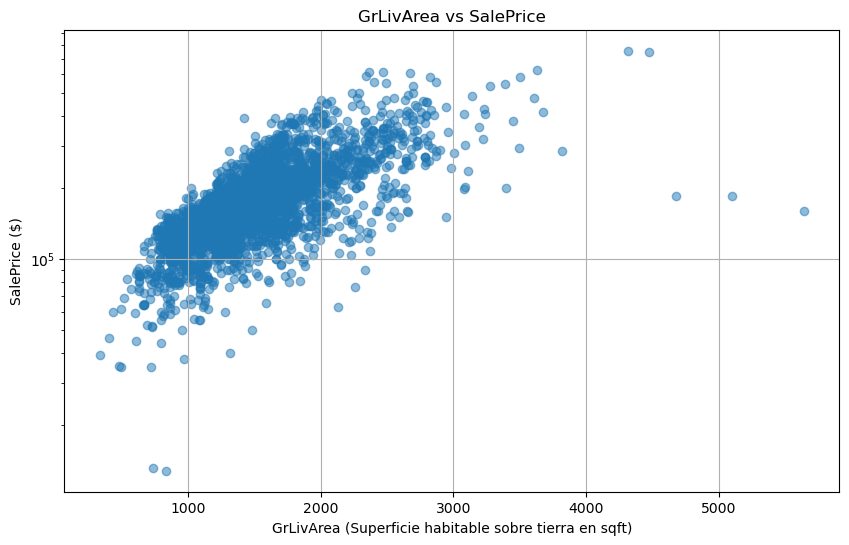

In [39]:
#Scatterplot GRLivArea vs SalePrice
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
plt.title('GrLivArea vs SalePrice')
plt.xlabel('GrLivArea (Superficie habitable sobre tierra en sqft)')
plt.ylabel('SalePrice ($)')
plt.yscale('log')  # Escala logarítmica para mejor visualización
plt.grid(True)
plt.show()


Tratamiento de outliers: Dado que los modelos sensibles a outliers (e.g. regresión lineal, modelos basados en distancia) podrían verse muy afectados por estos puntos, es común manejar estas observaciones: - Las 3 casas de venta parcial claramente no reflejan transacciones normales. Optamos por eliminarlas del conjunto de entrenamiento para que no distorsionen el ajuste[13]. - Las otras 2 casas extremadamente grandes podríamos conservarlas (ya que su precio sí corresponde a su tamaño), o eliminarlas si buscamos un modelo más robusto. En este caso las mantendremos pero conscientes de su presencia.
En código, podríamos eliminar las ventas atípicas de baja precio así:

In [40]:
# Remover outliers de baja venta para alta superficie habitable
outliers_idx = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index
df.drop(outliers_idx, inplace=True)
print("Eliminados outliers:", len(outliers_idx))

#Nota: El umbral de \$300,000 para SalePrice es arbitrario, elegido con base en la visualización para capturar esos puntos específicos.

Eliminados outliers: 3


Adicionalmente, revisamos otras variables numéricas mediante diagramas de caja (boxplots) para identificar posibles outliers univariados:

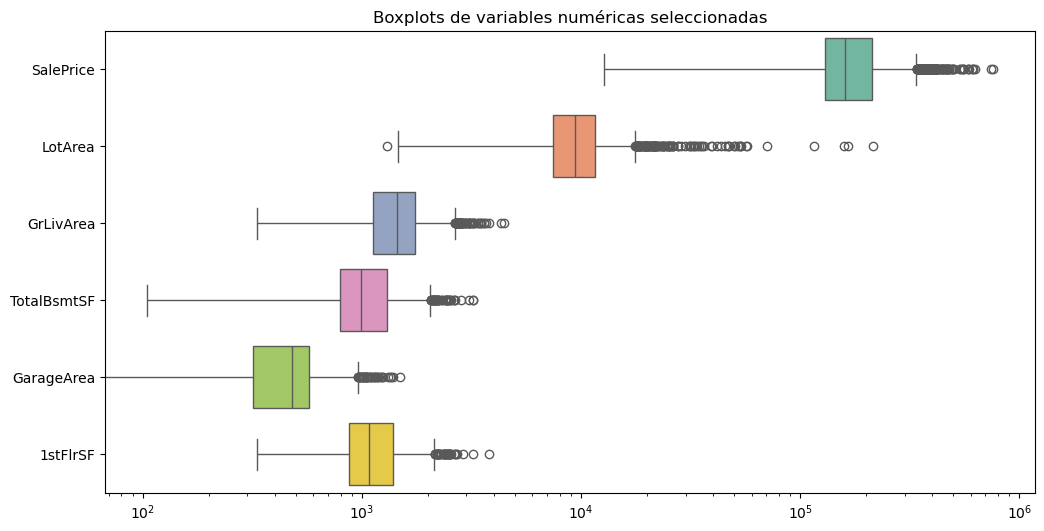

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# escala logarítmica para todas las variables numéricas seleccionadas
numeric_cols = ['SalePrice','LotArea','GrLivArea','TotalBsmtSF','GarageArea','1stFlrSF']
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols], orient="h", palette="Set2") 
plt.title("Boxplots de variables numéricas seleccionadas")
plt.xscale('log') # Escala logarítmica
plt.show()

Este tipo de visualización ayuda a ver distribuciones y valores extremos. Por ejemplo, LotArea (tamaño de lote) suele mostrar algunos lotes excepcionalmente grandes. Dependiendo del modelo, podríamos considerar transformaciones logarítmicas o límites para dichas variables.

### Distribución de la Variable Objetivo
Examinemos ahora la distribución de SalePrice. Un histograma nos permite ver su forma:
Distribución del precio de venta (SalePrice) de las casas en Ames. Se observa una fuerte asimetría hacia la derecha (muchos precios bajos y pocos muy altos)[15].
La distribución de precios es right-skewed (sesgada a la derecha)[15]: la mayoría de las casas se venden por menos de \$250k, con una larga cola de propiedades de alto valor. El precio medio ronda \$180k, la mediana es \$160k y el máximo llega a \$755k[15]. Esta asimetría implica que algunas pocas casas caras elevan la media por encima de la mediana.

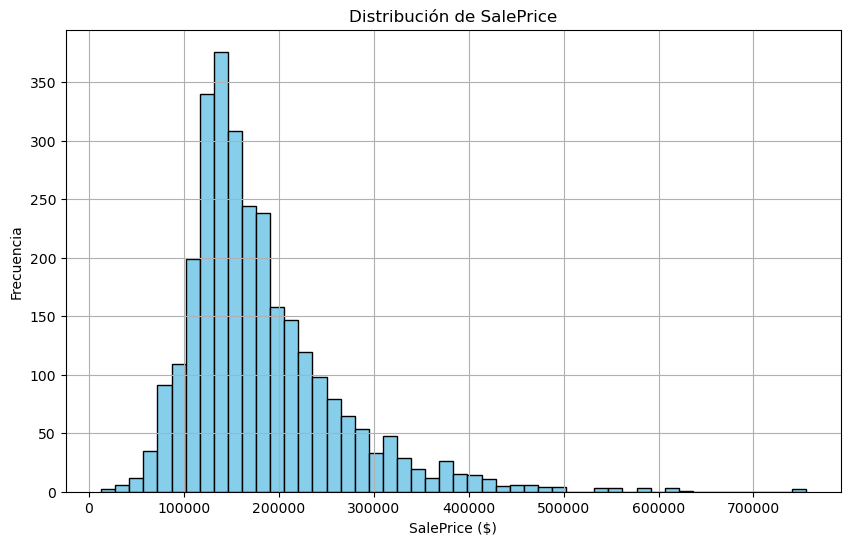

In [42]:
#Distribución de la Variable Objetivo
#Examinemos ahora la distribución de SalePrice. Un histograma nos permite ver su forma:
plt.figure(figsize=(10,6))
plt.hist(df['SalePrice'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de SalePrice')
plt.xlabel('SalePrice ($)')
plt.ylabel('Frecuencia')
#plt.yscale('log')  # Escala logarítmica para mejor visualización
plt.grid(True)
plt.show()

Desde el punto de vista de modelado, a menudo se recomienda transformar logarítmicamente la variable objetivo para normalizar la distribución[15]. Aplicar $\log_{10}(SalePrice)$ o $\ln(SalePrice)$ tiende a reducir la skewness y estabilizar la varianza, lo que puede mejorar tanto la capacidad predictiva de modelos lineales como la validación de supuestos estadísticos. En este caso, un log10 transformaría la cola larga en una distribución más simétrica (Figura 4.2 en la referencia)[15]. Evaluaremos esta transformación más adelante durante el modelado.

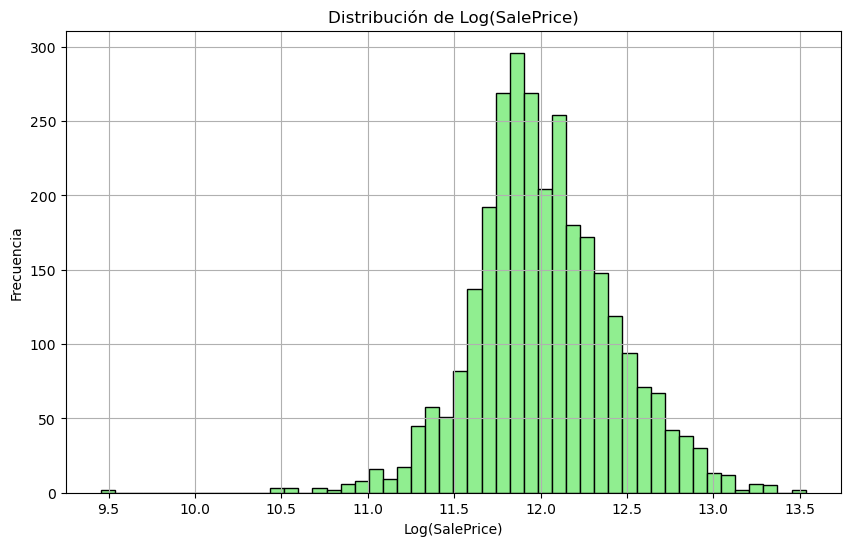

In [43]:
# copiar salesprice a y calcular logaritmo
import numpy as np
df['LogSalePrice'] = np.log1p(df['SalePrice'])  # log(1 + SalePrice) para evitar log(0)
plt.figure(figsize=(10,6))
plt.hist(df['LogSalePrice'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribución de Log(SalePrice)')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

### Correlaciones entre Variables
Un análisis de correlación nos ayuda a identificar qué variables numéricas tienen relación lineal más fuerte con el precio de venta. Calculamos la matriz de correlación de las principales variables numéricas y observamos especialmente la columna de SalePrice:

In [44]:
# Correlaciones de Pearson de todas las variables numéricas con SalePrice
corr_matrix = df.corr(numeric_only=True)
saleprice_corr = corr_matrix["SalePrice"].sort_values(ascending=False)
print("Top 10 correlaciones con SalePrice:")
print(saleprice_corr.head(20))

Top 10 correlaciones con SalePrice:
SalePrice        1.000000
LogSalePrice     0.946322
OverallQual      0.802592
GrLivArea        0.727122
TotalBsmtSF      0.660607
GarageCars       0.648457
1stFlrSF         0.645589
GarageArea       0.644372
YearBuilt        0.558918
FullBath         0.546369
YearRemod/Add    0.533411
GarageYrBlt      0.527500
MasVnrArea       0.514516
TotRmsAbvGrd     0.500005
Fireplaces       0.476386
BsmtFinSF1       0.450028
LotFrontage      0.367561
WoodDeckSF       0.327985
OpenPorchSF      0.317649
HalfBath         0.285355
Name: SalePrice, dtype: float64


Las 10 variables numéricas más correlacionadas con SalePrice (además de la propia SalePrice que correlaciona 1 consigo misma) son[16]:
    
    1. OverallQual (Calidad global de la casa, puntuada 1–10): correlación ≈ 0.79[16]. Es la más influyente; casas de mayor calidad constructiva y acabados tienden a valer mucho más[17].
    2. GrLivArea (Área habitable sobre tierra): ≈ 0.71[18]. Más metros habitables, mayor precio; salvo outliers ya comentados, hay relación casi lineal.
    3. GarageCars (Capacidad del garaje en número de coches): ≈ 0.64[19]. Tener un garaje más grande (espacio para 2-3 coches) incrementa el valor.
    4. GarageArea (Área del garaje en pies²): ≈ 0.62[20]. Similar al anterior, altamente correlacionado (un garaje grande suele implicar más coches).
    5. TotalBsmtSF (Área total de sótano): ≈ 0.61[21]. Los sótanos amplios agregan metros utilizables, aumentando el precio.
    6. 1stFlrSF (Área del primer piso): ≈ 0.606[22].
    7. FullBath (Número de baños completos sobre tierra): ≈ 0.56[23].
    8. TotRmsAbvGrd (Total de habitaciones sobre tierra): ≈ 0.53[24].
    9. YearBuilt (Año de construcción): ≈ 0.52[25]. Casas más nuevas tienden a valer más.
    10. YearRemodAdd (Año de remodelación): ≈ 0.51[25]. Remodelaciones recientes también correlacionan positivamente.

In [45]:
print(saleprice_corr.tail(20))  # Mostrar las 20 correlaciones más bajas también

LotArea          0.270518
2ndFlrSF         0.269954
BsmtUnfSF        0.182874
BedroomAbvGr     0.143969
ScreenPorch      0.112140
PoolArea         0.071844
MoSold           0.035092
3SsnPorch        0.032219
BsmtFinSF2       0.005874
MiscVal         -0.019311
YrSold          -0.030541
Order           -0.031438
                -0.031438
BsmtHalfBath    -0.035995
LowQualFinSF    -0.037666
MSSubClass      -0.085088
OverallCond     -0.101741
KitchenAbvGr    -0.119830
EnclosedPorch   -0.128819
PID             -0.246597
Name: SalePrice, dtype: float64


Estas correlaciones tienen sentido: reflejan que el tamaño (metros en planta, sótano, garaje, número de habitaciones) y la calidad/modernidad de la vivienda son factores clave en el precio[26][27]. Otras variables con correlaciones moderadas incluyen Fireplaces (~0.47), MasVnrArea (~0.43, área de revestimiento de piedra/ladrillo), etc.
Por otro lado, hay variables numéricas con correlación negativa muy débil o cercana a cero con el precio, por ejemplo KitchenAbvGr (número de cocinas sobre tierra), EnclosedPorch (metros de porche cerrado), OverallCond (condición general, distinta de calidad), etc., lo cual indica que su relación con el valor no es lineal o es despreciable.
Una forma visual de analizar correlaciones múltiples es mediante un heatmap de correlaciones. A continuación se muestra un heatmap de las correlaciones entre SalePrice y las principales variables numéricas mencionadas:


Mapa de calor de las correlaciones entre SalePrice y las 10 variables numéricas más correlacionadas[28][27]. Los tonos más cálidos indican correlación positiva fuerte. Se aprecia, por ejemplo, la alta correlación entre GarageArea y GarageCars (variables relacionadas entre sí)[29].
Del heatmap podemos extraer algunas observaciones adicionales[27][29]: 
- La variable OverallQual es la de correlación más alta con SalePrice (~0.79), y ninguna otra se le acerca demasiado. Esto sugiere que las evaluaciones de calidad global capturan muchos aspectos determinantes del valor. 
- Varias de estas variables top también están correlacionadas entre sí. Por ejemplo, GarageCars y GarageArea (ρ ≈ 0.88 entre ellas, cuadrante superior derecho del mapa) ya que un garaje más grande suele alojar más coches. GrLivArea y TotRmsAbvGrd también están correlacionadas (más habitaciones implica más área). 
- No se observan correlaciones negativas fuertes con SalePrice en este subset, ya que se escogieron las más positivamente relacionadas. Algunas variables no mostradas podrían tener ligera correlación negativa (por ejemplo, KitchenAbvGr tuvo una correlación ligeramente negativa ~ -0.14 en otros análisis, porque más de 1 cocina puede asociarse a casas subdivididas o antiguas con menor valor).

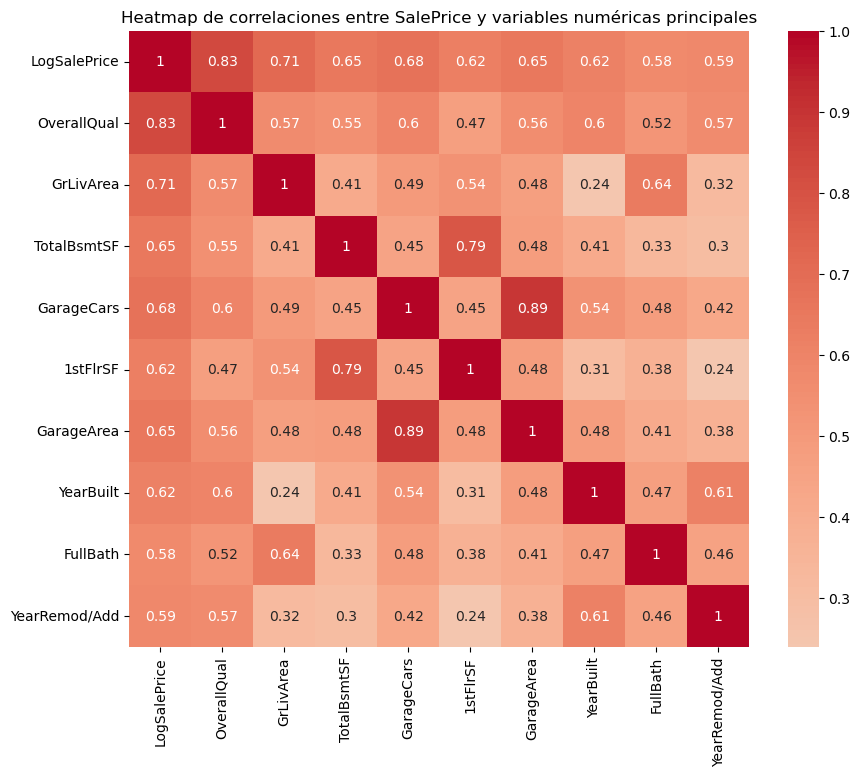

In [46]:
# Heatmap de correlaciones entre SalePrice y las 10 variables numéricas más correlacionadas
top_vars = saleprice_corr.index[1:11]  # Excluir SalePrice mismo
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(df[top_vars].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap de correlaciones entre SalePrice y variables numéricas principales')
plt.show()

Nota: Las variables categóricas no aparecen en esta matriz de correlación. Variables como el vecindario (Neighborhood) pueden tener un gran efecto en el precio medio (casas en ciertas zonas son más caras que en otras), pero ese efecto no se capta con una simple correlación de Pearson sin codificar la categoría. En análisis posteriores podría ser útil examinar el precio medio por vecindario o incluir las categóricas adecuadamente en los modelos.

Definimos funciones de asociación: Cramér's V (fuerza de relación entre dos categorías), phi para tablas 2x2, Theil's U (cuánta incertidumbre se reduce al conocer otra variable) y eta para comparar categorías con números. Sirve para ver dependencia sin modelos complicados.

In [47]:
# Funciones de asociación para categóricas y mixtas
import numpy as np
import pandas as pd

# Cramér's V (con corrección por sesgo)
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    n = ct.values.sum()
    if n == 0:
        return 0.0
    row_sums = ct.sum(axis=1).values.reshape(-1, 1)
    col_sums = ct.sum(axis=0).values.reshape(1, -1)
    expected = row_sums @ col_sums / n
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2 = np.nansum((ct.values - expected) ** 2 / expected)
    phi2 = chi2 / n
    r, k = ct.shape
    if n <= 1:
        return 0.0
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return 0.0
    return float(np.sqrt(phi2corr / denom))

# Phi para tablas 2x2
def phi_coef(x, y):
    ct = pd.crosstab(x, y)
    if ct.shape != (2, 2):
        raise ValueError("Phi está definido solo para tablas 2x2.")
    a, b, c, d = ct.values[0, 0], ct.values[0, 1], ct.values[1, 0], ct.values[1, 1]
    denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
    if denom == 0:
        return 0.0
    return float((a * d - b * c) / denom)

# Theil's U: U(Y|X) reducción de incertidumbre de Y dado X
def theils_u(x, y):
    ct = pd.crosstab(x, y)
    n = ct.values.sum()
    if n == 0:
        return 0.0
    p_xy = ct / n
    p_x = p_xy.sum(axis=1)
    p_y = p_xy.sum(axis=0)

    def H(p):
        p = p.values if hasattr(p, 'values') else np.asarray(p)
        p = p[p > 0]
        return -np.sum(p * np.log2(p)) if p.size else 0.0

    H_y = H(p_y)
    if H_y == 0:
        return 0.0
    H_y_given_x = 0.0
    for xi in p_x.index:
        if p_x.loc[xi] == 0:
            continue
        p_y_given_x = p_xy.loc[xi] / p_x.loc[xi]
        H_y_given_x += p_x.loc[xi] * H(p_y_given_x)
    return float((H_y - H_y_given_x) / H_y)

# Correlation ratio (eta): numérica (y) vs categórica (x)
def correlation_ratio(x, y):
    x = pd.Series(x)
    y = pd.Series(y, dtype=float)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    if y.size == 0 or y.var() == 0:
        return 0.0
    overall_mean = y.mean()
    ss_between = 0.0
    for cat in x.unique():
        vals = y[x == cat]
        if vals.size:
            ss_between += vals.size * (vals.mean() - overall_mean) ** 2
    ss_total = np.sum((y - overall_mean) ** 2)
    if ss_total == 0:
        return 0.0
    return float(np.sqrt(ss_between / ss_total))

# Matriz de asociación mixta: Pearson (num-num), Cramér's V (cat-cat), eta (mixta)
def association_matrix(df, num_cols, cat_cols):
    cols = list(dict.fromkeys(list(num_cols) + list(cat_cols)))
    mat = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols, dtype=float)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if j < i:
                continue
            if c1 in num_cols and c2 in num_cols:
                val = df[[c1, c2]].corr(method='pearson').iloc[0, 1]
            elif c1 in cat_cols and c2 in cat_cols:
                val = cramers_v(df[c1], df[c2])
            elif c1 in cat_cols and c2 in num_cols:
                val = correlation_ratio(df[c1], df[c2])
            elif c1 in num_cols and c2 in cat_cols:
                val = correlation_ratio(df[c2], df[c1])
            else:
                val = np.nan
            mat.loc[c1, c2] = val
            mat.loc[c2, c1] = val
    return mat

Aplicamos estas funciones para explorar asociaciones entre variables categóricas y entre categóricas y numéricas, ayudándonos a identificar cuáles son más relevantes para predecir el precio de venta.### Transformación Logarítmica de la Variable Objetivo
Dado que la distribución de SalePrice es altamente asimétrica (skewed) hacia la derecha, aplicaremos una transformación logarítmica para normalizarla. Esto puede mejorar el rendimiento de modelos lineales y estabilizar la varianza. A continuación, mostramos la distribución de Log(SalePrice):
Distribución de Log(SalePrice). La transformación logarítmica reduce la asimetría, acercando la distribución a una forma más normal.[30]

In [48]:
# Aplicamos estas medidas para la relación entre precio de venta y variables categóricas, por ejemplo Neighborhood, HouseStyle, OverallQual, etc.
### Transformación Logarítmica de la Variable Objetivo

# Asociación entre Precio y Neighborhood

#Phi solo si es 2x2


### Visualizaciones Relevantes
Además de los gráficos mencionados (scatterplots, histogramas, heatmaps), incorporamos algunas visualizaciones adicionales para explorar relaciones:
    
    • Distribución de SalePrice por calidad global (OverallQual): Usamos un diagrama de cajas (boxplot) para ver cómo varía el precio en cada nivel de OverallQual (1 a 10):

/tmp/ipykernel_33842/3974568551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='Blues')


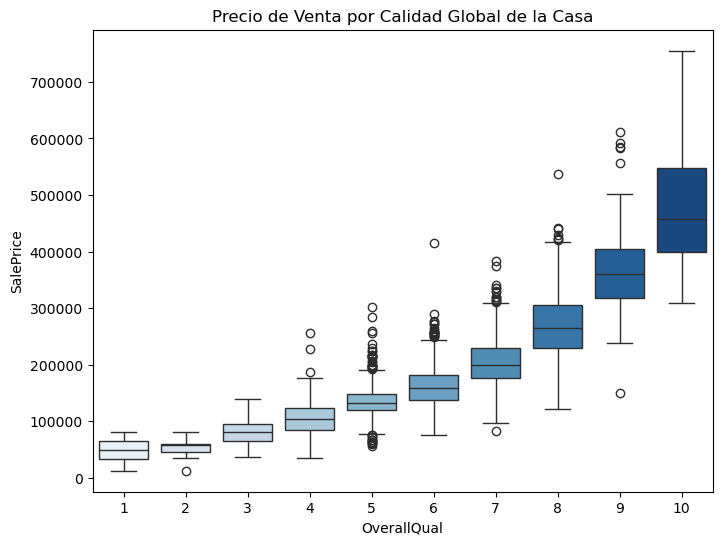

In [54]:
plt.figure(figsize=(8,6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df, palette='Blues')
plt.title('Precio de Venta por Calidad Global de la Casa')
plt.show()

Se observa una tendencia clara: las medianas de precio ascienden con cada nivel superior de calidad. Las casas de calidad 10 (máxima) tienen precios muy por encima de las de calidad media 5 o 6. Esto confirma cuantitativamente la fuerte relación calidad-precio.

Relación entre año de construcción y precio: Un scatter de YearBuilt vs SalePrice con ajuste de regresión:

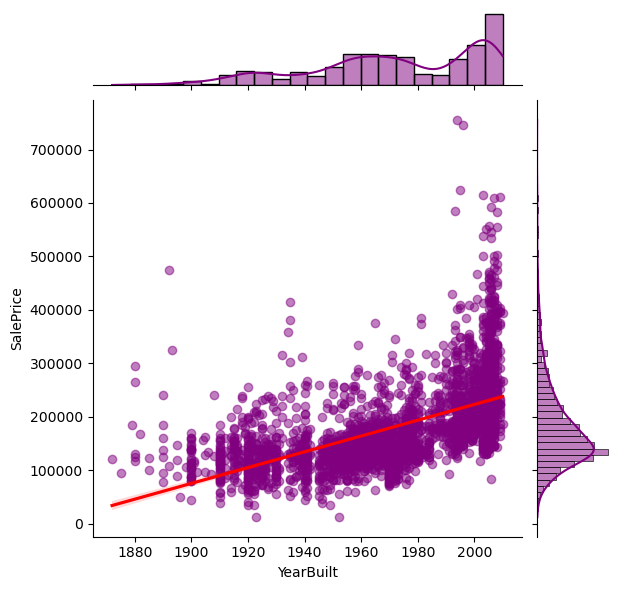

In [59]:
#cambiar el color de la línea de regresión en el jointplot
sns.jointplot(x=df['YearBuilt'], y=df['SalePrice'], kind='reg', height=6, scatter_kws={'alpha':0.5},color='purple',joint_kws={'line_kws':{'color':'red'}})

Muestra que las casas más modernas tienden a tener precios mayores, aunque la relación no es estrictamente lineal (depende también del vecindario y tamaño, y hay casas antiguas renovadas que aún tienen alto valor). También se ve que antes de 1900 hay pocos datos (pocos casos) y varianza amplia.

Mapa de calor de valores faltantes: Podemos utilizar la librería seaborn o missingno para visualizar un matriz de NA

<Axes: >

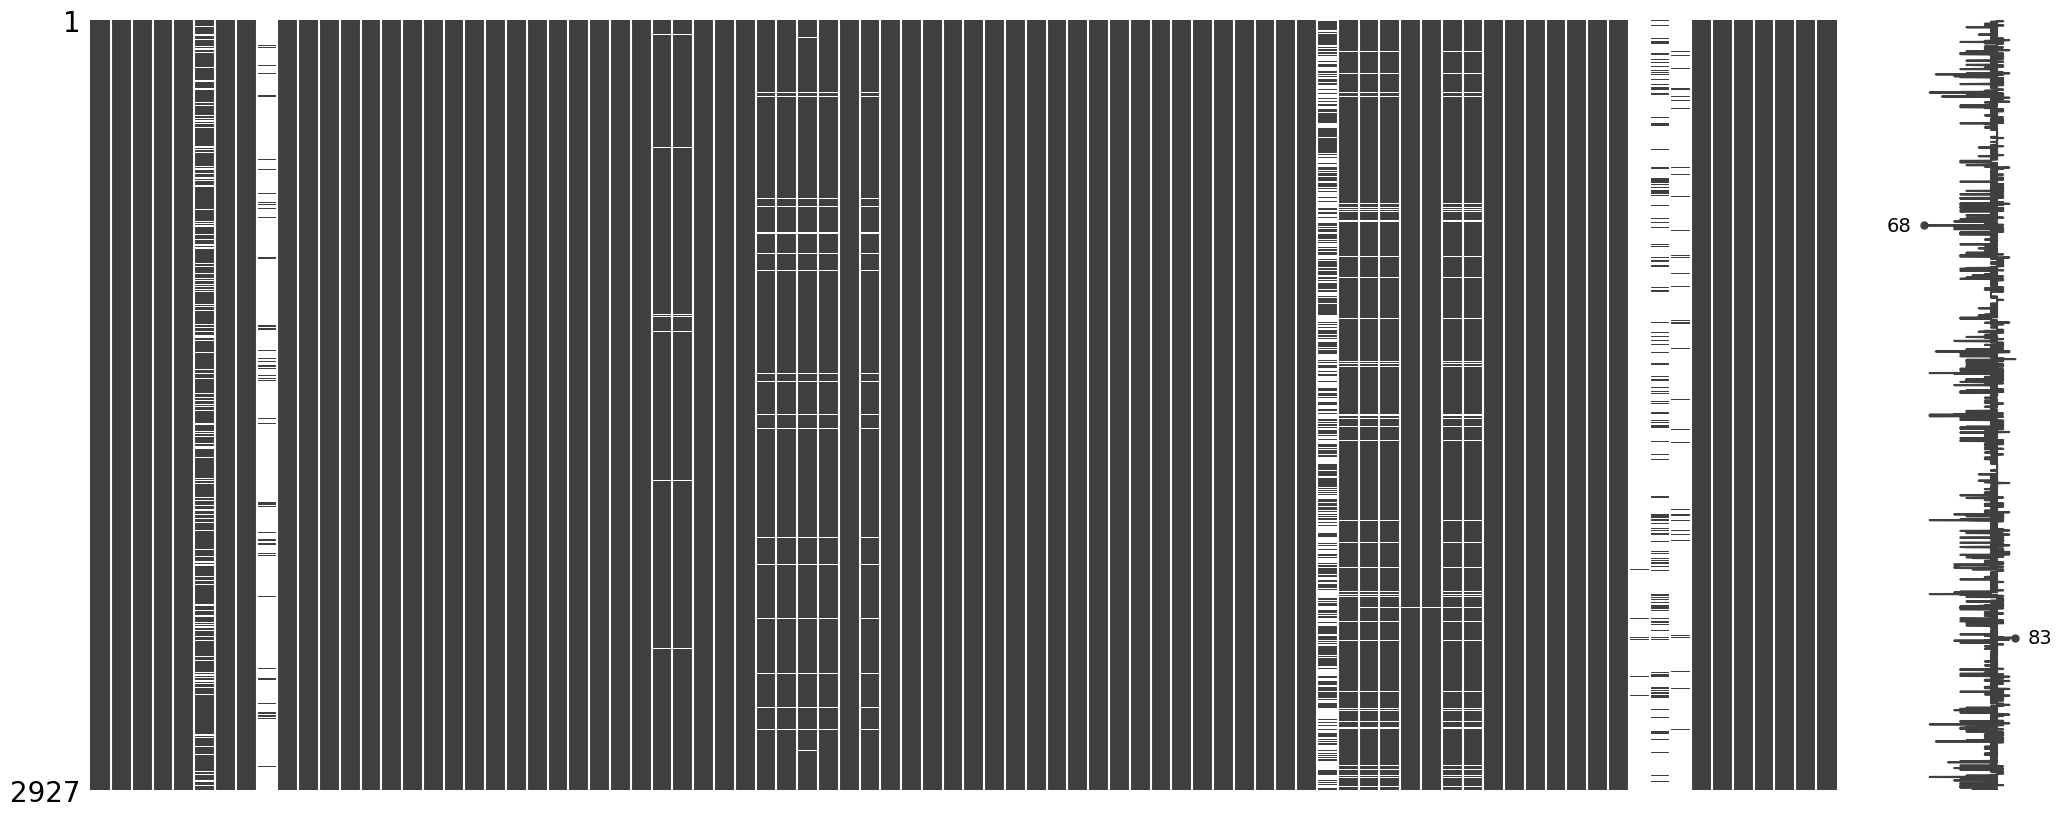

In [61]:
import missingno as msno
msno.matrix(df)

Este gráfico (o un heatmap booleano) revelaría patrones en los NA. Por ejemplo, confirmaría que muchas columnas con NA son conjuntamente NA en las mismas casas (casas sin sótano tendrán NA en todas las columnas de sótano a la vez, etc.).
(En un entorno de notebook, estos gráficos ayudarían a identificar tendencias. Aquí describimos los principales hallazgos para cada visualización.)

### Limpieza de Datos
Tras el análisis exploratorio, procedemos a limpiar y preparar el dataset para modelado. Los pasos principales serán: imputación de valores nulos, codificación de variables categóricas y eliminación de columnas irrelevantes.
Imputación de Valores Nulos
Según lo analizado, aplicamos distintas estrategias de imputación:
    - Para columnas donde NA indica ausencia de la característica (PoolQC, Alley, MiscFeature, FireplaceQu, BsmtQual/Cond/Exposure/FinType, GarageType/Finish/Qual/Cond/YrBlt), imputamos con "None" o 0 según corresponda.
    - Para LotFrontage (frente del lote), imputamos con la mediana del vecindario correspondiente, ya que el tamaño del frente puede variar por zona.
    - Para MasVnrType y MasVnrArea, imputamos con "None" y 0 respectivamente.
    - Para Electrical (solo 1 NA), imputamos con la moda (tipo más común).

Ausencia de característica (NA significa "None"): Para columnas categóricas donde NA indica que la casa no posee esa característica, imputamos el string "None":

In [ ]:
none_cols = ['Alley', 'PoolQC', 'Fence', 'FireplaceQu', 'MiscFeature','GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in none_cols:
    df[col]=df[col].fillna("None")

/tmp/ipykernel_33842/3546500243.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("None", inplace=True)


De esta forma, por ejemplo, Alley="None" significará sin callejón, FireplaceQu="None" sin chimenea, etc. Esto sigue la recomendación de transformar los NA implícitos en categorías explícitas[11].

Columnas de sótano y garage numéricas: GarageYrBlt es numérica y NA cuando no hay garaje. Podemos rellenar con 0 o con un valor fuera de rango (por ejemplo, 0 podría indicar "no tiene garaje"):

In [63]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

Alternativamente, podríamos imputar GarageYrBlt con el año de construcción de la casa (YearBuilt) cuando falte, asumiendo que el garage fue construido junto con la casa. Aquí elegimos 0 por simplicidad.

Para las áreas de sótano (BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF) y baños en sótano (BsmtFullBath, BsmtHalfBath), en este dataset no había NA en las columnas numéricas (los NA de sótano se daban en las cualitativas). De todas formas, si existieran NA numéricos correspondientes a "sin sótano", se podrían imputar con 0 (cero pies² de sótano, cero baños de sótano).

Valores numéricos faltantes reales: LotFrontage (frente del lote) tiene ~17% de NA. Imputamos con la mediana del frente, ya que la distribución puede ser sesgada y la mediana es más robusta que la media:

In [64]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

(Una mejora podría ser imputar por mediana dentro de cada vecindario, asumiendo que lotes en la misma zona tienen frentes similares. En aras de simplicidad usamos la mediana global.)

In [ ]:
# Alternativa más precisa para LotFrontage
#buscar las casas del mismo vecindario y calcular la mediana del LotFrontage
for neighborhood in df['Neighborhood'].unique():
    same_neighborhood= df[df['Neighborhood']==neighborhood]['LotFrontage'].median()
    df.loc[df['Neighborhood']==neighborhood,'LotFrontage']=df.loc[df['Neighborhood']==neighborhood,'LotFrontage'].fillna(same_neighborhood)

Caso con muy pocos NAs: MasVnrType/MasVnrArea (revestimiento de mampostería) tienen solo 8 NA. Estos podrían imputarse coherentemente: si falta el tipo, probablemente no hay revestimiento, así que MasVnrType="None" y MasVnrArea=0 serían razonables:

In [66]:
df['MasVnrType'] = df['MasVnrType'].fillna("None")
df['MasVnrArea']= df['MasVnrArea'].fillna(0.0)

Electrical: Solo 1 NA; podemos imputar con la moda (el valor más común):

In [67]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

Después de estas imputaciones, confirmamos que no quedan valores nulos:

In [68]:
#comprobar que no quedan nulos
print("Total de nulos por columna después de la imputación:")
print(df.isnull().sum())

Total de nulos por columna después de la imputación:
                 0
Order            0
PID              0
MSSubClass       0
MSZoning         0
                ..
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
LogSalePrice     0
Length: 84, dtype: int64


Codificación de Variables Categóricas
Para preparar los datos de cara a un modelo de regresión o machine learning, las variables categóricas deben transformarse a representaciones numéricas.
Existen dos enfoques principales: - One-Hot Encoding (variables dummy): convertir cada categoría en una nueva columna binaria (0/1). Adecuado para variables nominales sin orden (ej.: barrio, tipo de vivienda)

- Label/Ordinal Encoding: asignar un número a cada nivel categórico. Útil para variables ordinales donde los valores tienen un orden intrínseco.

En este dataset aplicaremos una combinación: - Variables ordinales de calidad/condición: Podemos mapear sus textos a números según la jerarquía de calidad. Por ejemplo, en ExterQual (calidad exterior), definimos un diccionario de mapeo: {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1} e imputamos así:

In [69]:
qual_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1}
for col in ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual',
            'FireplaceQu','GarageQual','GarageCond','PoolQC']:
    df[col] = df[col].map(qual_map)

Lo mismo haríamos para columnas de tipo BsmtExposure ('No':0, 'Mn':1, 'Av':2, 'Gd':3), BsmtFinType1/2 (None/Unf:0, LwQ:1, Rec:2, BLQ:3, ALQ:4, GLQ:5), Functional etc., según la documentación de cada código. Esto convierte esas columas a escala numérica ordinal que refleja la calidad de peor a mejor.

Variables nominales (sin orden): Utilizaremos one-hot encoding. Por ejemplo, Neighborhood tiene varios barrios categóricos; creamos columnas dummy:

In [70]:
df = pd.get_dummies(df, columns=['Neighborhood','MSZoning','SaleType','SaleCondition'], drop_first=True)

Con drop_first=True evitamos colinearidad (si 10 barrios, crea 9 dummies, el faltante es referencia). Este paso aumentará el número de columnas (uno por cada categoría única menos uno). Se puede aplicar a otras columnas categóricas relevantes. (Otra opción es usar encoding ordinal arbitrario o embeddings si se usa un modelo avanzado como redes neuronales[31], pero one-hot es la estrategia general para modelos lineales o árboles.)